<a href="https://colab.research.google.com/github/mvenkataRaviTeja/kidney_failure_prediction-model/blob/main/kideny_ML_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report,
                             RocCurveDisplay)

In [ ]:
import pandas as pd
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Chronic_Kidney_Dsease_data.csv')

# Display first rows
print(df.head())

   PatientID  Age  Gender  Ethnicity  SocioeconomicStatus  EducationLevel  \
0          1   71       0          0                    0               2   
1          2   34       0          0                    1               3   
2          3   80       1          1                    0               1   
3          4   40       0          2                    0               1   
4          5   43       0          1                    1               2   

         BMI  Smoking  AlcoholConsumption  PhysicalActivity  ...   Itching  \
0  31.069414        1            5.128112          1.676220  ...  7.556302   
1  29.692119        1           18.609552          8.377574  ...  6.836766   
2  37.394822        1           11.882429          9.607401  ...  2.144722   
3  31.329680        0           16.020165          0.408871  ...  7.077188   
4  23.726311        0            7.944146          0.780319  ...  3.553118   

   QualityOfLifeScore  HeavyMetalsExposure  OccupationalExposureChem

In [ ]:
print(df.describe())

         PatientID          Age       Gender   Ethnicity  SocioeconomicStatus  \
count  1659.000000  1659.000000  1659.000000  1659.00000          1659.000000   
mean    830.000000    54.441230     0.515371     0.71308             0.977697   
std     479.056364    20.549757     0.499914     1.00043             0.776686   
min       1.000000    20.000000     0.000000     0.00000             0.000000   
25%     415.500000    36.000000     0.000000     0.00000             0.000000   
50%     830.000000    54.000000     1.000000     0.00000             1.000000   
75%    1244.500000    72.000000     1.000000     1.00000             2.000000   
max    1659.000000    90.000000     1.000000     3.00000             2.000000   

       EducationLevel          BMI      Smoking  AlcoholConsumption  \
count     1659.000000  1659.000000  1659.000000         1659.000000   
mean         1.693189    27.620049     0.292948            9.969831   
std          0.910611     7.288670     0.455252          

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PatientID                      1659 non-null   int64  
 1   Age                            1659 non-null   int64  
 2   Gender                         1659 non-null   int64  
 3   Ethnicity                      1659 non-null   int64  
 4   SocioeconomicStatus            1659 non-null   int64  
 5   EducationLevel                 1659 non-null   int64  
 6   BMI                            1659 non-null   float64
 7   Smoking                        1659 non-null   int64  
 8   AlcoholConsumption             1659 non-null   float64
 9   PhysicalActivity               1659 non-null   float64
 10  DietQuality                    1659 non-null   float64
 11  SleepQuality                   1659 non-null   float64
 12  FamilyHistoryKidneyDisease     1659 non-null   i

In [ ]:
print(df.columns)

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'SocioeconomicStatus',
       'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption',
       'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryKidneyDisease', 'FamilyHistoryHypertension',
       'FamilyHistoryDiabetes', 'PreviousAcuteKidneyInjury',
       'UrinaryTractInfections', 'SystolicBP', 'DiastolicBP',
       'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'GFR',
       'ProteinInUrine', 'ACR', 'SerumElectrolytesSodium',
       'SerumElectrolytesPotassium', 'SerumElectrolytesCalcium',
       'SerumElectrolytesPhosphorus', 'HemoglobinLevels', 'CholesterolTotal',
       'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides',
       'ACEInhibitors', 'Diuretics', 'NSAIDsUse', 'Statins',
       'AntidiabeticMedications', 'Edema', 'FatigueLevels', 'NauseaVomiting',
       'MuscleCramps', 'Itching', 'QualityOfLifeScore', 'HeavyMetalsExposure',
       'OccupationalExposureChemicals', 'WaterQu

In [ ]:
print(df.shape)

(1659, 54)


In [ ]:
print(df.size)

89586


In [ ]:
# Remove unwanted spaces
df = df.replace('\t?', np.nan)
df = df.replace('?', np.nan)

# Check missing values
print(df.isnull().sum())

# Encode categorical columns
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])

# Fill missing values
imputer = SimpleImputer(strategy='most_frequent')
df = pd.DataFrame(imputer.fit_transform(df),
                  columns=df.columns)

PatientID                        0
Age                              0
Gender                           0
Ethnicity                        0
SocioeconomicStatus              0
EducationLevel                   0
BMI                              0
Smoking                          0
AlcoholConsumption               0
PhysicalActivity                 0
DietQuality                      0
SleepQuality                     0
FamilyHistoryKidneyDisease       0
FamilyHistoryHypertension        0
FamilyHistoryDiabetes            0
PreviousAcuteKidneyInjury        0
UrinaryTractInfections           0
SystolicBP                       0
DiastolicBP                      0
FastingBloodSugar                0
HbA1c                            0
SerumCreatinine                  0
BUNLevels                        0
GFR                              0
ProteinInUrine                   0
ACR                              0
SerumElectrolytesSodium          0
SerumElectrolytesPotassium       0
SerumElectrolytesCal

In [ ]:
X = df.drop('Diagnosis', axis=1)   # Target column
y = df['Diagnosis']

# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(1327, 53) (332, 53)


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Chronic_Kidney_Dsease_data.csv')

# Replace missing value symbols
df.replace('?', pd.NA, inplace=True)
df.replace('\t?', pd.NA, inplace=True)

# Remove extra spaces from string columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip()

# Initialize Label Encoder
le = LabelEncoder()

# Find categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

# Apply Label Encoding to each categorical column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Display first few rows after encoding
print("\nEncoded Dataset:")
print(df.head())

Categorical Columns:
Index(['DoctorInCharge'], dtype='object')

Encoded Dataset:
   PatientID  Age  Gender  Ethnicity  SocioeconomicStatus  EducationLevel  \
0          1   71       0          0                    0               2   
1          2   34       0          0                    1               3   
2          3   80       1          1                    0               1   
3          4   40       0          2                    0               1   
4          5   43       0          1                    1               2   

         BMI  Smoking  AlcoholConsumption  PhysicalActivity  ...   Itching  \
0  31.069414        1            5.128112          1.676220  ...  7.556302   
1  29.692119        1           18.609552          8.377574  ...  6.836766   
2  37.394822        1           11.882429          9.607401  ...  2.144722   
3  31.329680        0           16.020165          0.408871  ...  7.077188   
4  23.726311        0            7.944146          0.780319  ...  


Target Column: Diagnosis

XGBoost
Accuracy : 0.9246987951807228
Precision: 0.9516129032258065
Recall   : 0.9672131147540983
F1 Score : 0.959349593495935
ROC AUC  : 0.9577413479052823


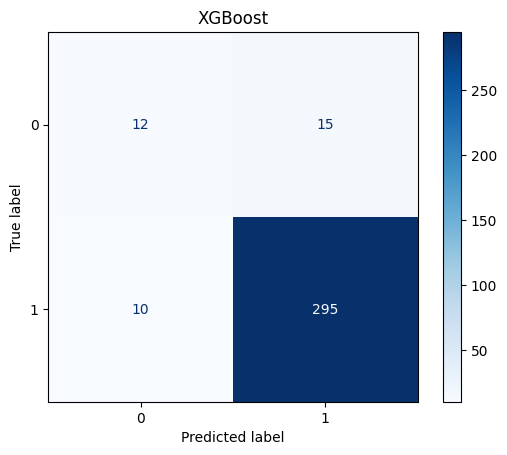

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("/content/drive/MyDrive/Chronic_Kidney_Dsease_data.csv")
# -----------------------------
# Target Column
# -----------------------------
target = 'Diagnosis' # Corrected target to 'Diagnosis'

print("\nTarget Column:", target)

# Convert target to numeric if needed
if df[target].dtype == 'object':
    df[target] = df[target].astype('category').cat.codes

X = df.drop(columns=[target])
y = df[target]

# -----------------------------
# Identify Numerical & Categorical Columns
# -----------------------------
numeric_features = X.select_dtypes(include=['int64','float64']).columns

categorical_features = X.select_dtypes(include=['object']).columns

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))
# -----------------------------
# Preprocessing
# -----------------------------
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# -----------------------------
# Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Models
# -----------------------------
models = {
    "XGBoost":
        XGBClassifier(
            eval_metric='logloss',
            random_state=42
        ),
}

# -----------------------------
# Train & Evaluate
# -----------------------------
results = []

for name, model in models.items():

    current_pipeline = Pipeline([ # Changed variable name to avoid confusion with global 'pipeline'
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    current_pipeline.fit(X_train, y_train)

    if name == "XGBoost":
        xgb_full_pipeline = current_pipeline # Store the fitted XGBoost pipeline globally

    y_pred = current_pipeline.predict(X_test)

    y_prob = current_pipeline.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

    print("\n", "="*50)
    print(name)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("ROC AUC  :", roc)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(cm)

    disp.plot(cmap="Blues")

    plt.title(name)

    plt.show()

### Feature Importance for XGBoost Model

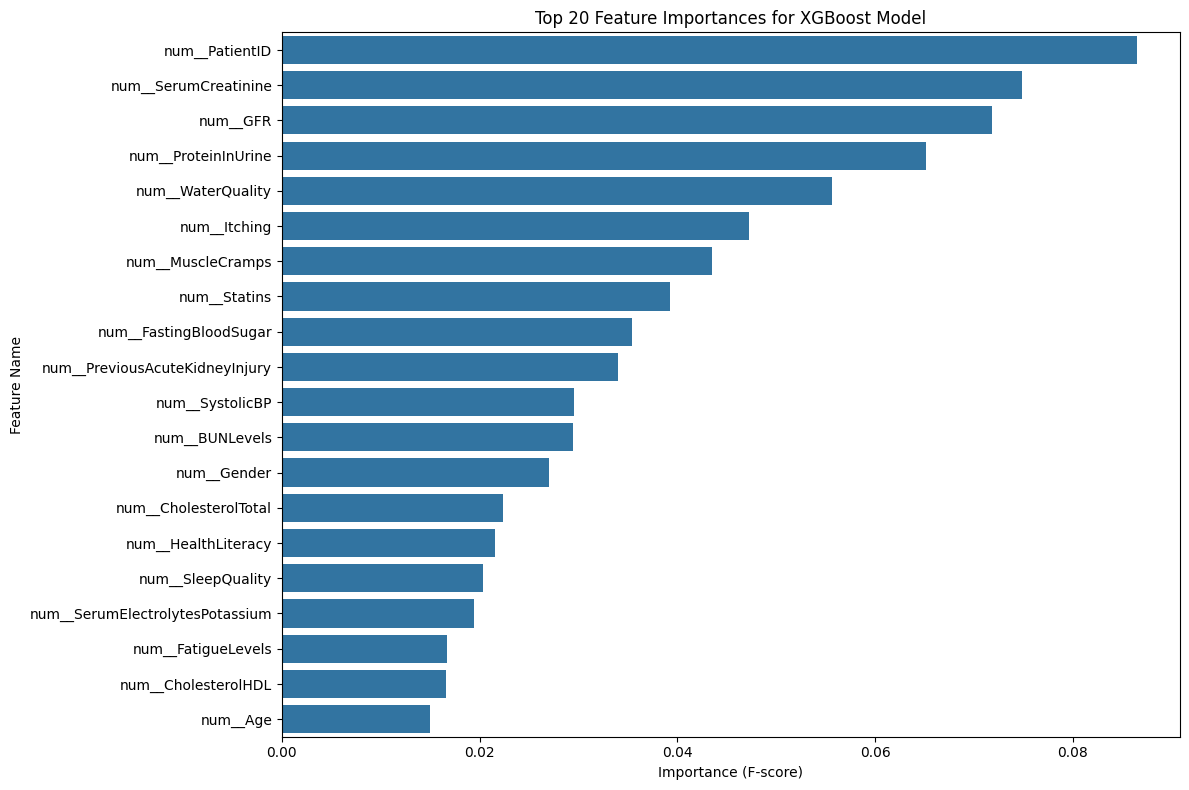

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Access the trained XGBoost model from the pipeline (now using xgb_full_pipeline)
xgb_model = xgb_full_pipeline.named_steps['classifier']

# Get feature names after preprocessing
# This requires fitting the preprocessor separately on X_train to get transformed feature names
# However, the pipeline itself has been fitted, so we can access `get_feature_names_out` directly
# from the preprocessor within the fitted pipeline.
preprocessor_fitted = xgb_full_pipeline.named_steps['preprocessor']
feature_names_transformed = preprocessor_fitted.get_feature_names_out()

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names_transformed,
    'Importance': xgb_model.feature_importances_
})

# Sort by importance and display the top features
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importances for XGBoost Model')
plt.xlabel('Importance (F-score)')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

Confusion Matrix:
[[ 12  15]
 [ 10 295]]


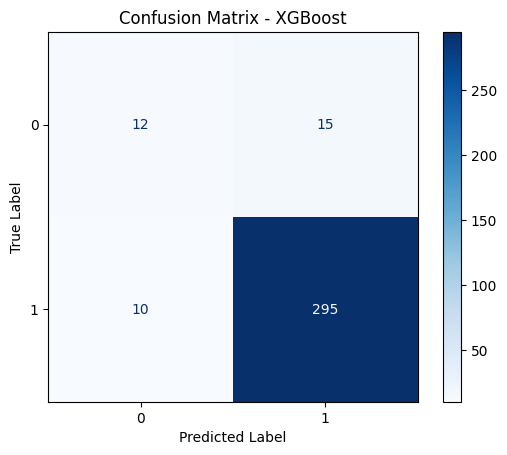

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np # Import numpy
from sklearn.model_selection import train_test_split # Import train_test_split

# Re-create y_test and y_pred to ensure they are defined in this cell's scope
# Assuming X, y, and xgb_full_pipeline are available from previous cells.
# This duplicates the train_test_split call from the model training cell.
# X, y should be the raw features and target before any preprocessing within the pipeline.
# The X and y from the kernel state are before pipeline processing, which is correct.

# First, identify the original X and y that were used for the split in the training cell.
# Based on cell R5a7hJ-nM3Br, X and y were created after loading the dataset and converting target to numeric.
# We need to ensure these original X and y are available.
# Given the kernel state, X and y are available as pandas DataFrames/Series.

_, _, _, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_pred = xgb_full_pipeline.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.unique(y_test) # Use unique values from y_test as labels
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()